# Poisson Dataset — Exploratory Data Analysis 

This notebook is AI-Generated.

Exploring the `PoissonGenerator` dataset from `flowpde.datasets.exponax.poisson`.

The generator produces source → solution pairs for the 2D periodic Poisson equation

$$-\nabla^2 u = f$$

where the source $f$ is a random smooth mixture of sine terms and $u$ is obtained via an exact spectral solve (division by $|k|^2$ in Fourier space, with the zero mode fixed to keep $u$ mean-zero).

This notebook covers:
1. Dataset generation & basic stats
2. Sample visualization (source / solution pairs)
3. Value & per-sample norm distributions
4. Spatial statistics (pixel-wise mean/std maps)
5. Spectral (power spectrum) analysis
6. A numerical sanity check that the generated pairs actually satisfy $-\nabla^2 u = f$
7. Effect of `source_max_mode` / `source_num_terms` on complexity
8. The inverse problem with partial, noisy observations
9. Field normalization for training

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
from flowpde.datasets.exponax.poisson import PoissonConfig, PoissonGenerator
from flowpde.datasets.normalization import FieldNormalizer

## 1. Generate the Dataset

Configure `PoissonConfig` and generate a forward dataset (`source → solution`).

In [3]:
poisson_cfg = PoissonConfig(
    num_spatial_dims=2,
    num_points=64,
    domain_extent=10.0,
    num_samples=500,
    seed=42,
    source_num_terms=4,   # number of sine terms mixed per source field
    source_max_mode=4,    # largest integer wavenumber sampled per dimension
)

poisson_gen = PoissonGenerator(config=poisson_cfg)
poisson_dataset = poisson_gen.generate(problem='forward')

# Raw tensors, shape (N, 1, H, W)
poisson_data = poisson_dataset.get_raw_data()
source = poisson_data['source'].numpy()      # (N, 1, 64, 64)
solution = poisson_data['solution'].numpy()  # (N, 1, 64, 64)

n_samples, _, H, W = source.shape

print(f"Config: {poisson_dataset.get_config()}")
print(f"\nData keys: {list(poisson_data.keys())}")
print(f"Source shape:   {source.shape}")
print(f"Solution shape: {solution.shape}")

Generated Poisson 2D dataset: 500 samples, 64x64 grid
Config: {'num_spatial_dims': 2, 'num_points': 64, 'domain_extent': 10.0, 'num_samples': 500, 'seed': 42, 'torch_device': 'cpu', 'obs_noise_std': 0.0, 'obs_mask_fraction': 1.0, 'order': 2, 'source_num_terms': 4, 'source_max_mode': 4}

Data keys: ['source', 'solution']
Source shape:   (500, 1, 64, 64)
Solution shape: (500, 1, 64, 64)


## 2. Basic Statistics

Dataset-level statistics come pre-computed on `poisson_dataset.get_stats()`. We also compute per-sample $L^2$ norms, which describe how "energetic" individual source/solution fields are.

In [4]:
stats = poisson_dataset.get_stats()
for field, s in stats.items():
    print(f"{field:>10s}:  mean={s['mean']:+.4f}  std={s['std']:.4f}  "
          f"min={s['min']:+.4f}  max={s['max']:.4f}")

# Per-sample L2 norms (energy of each field)
source_norms = np.linalg.norm(source.reshape(n_samples, -1), axis=-1)
solution_norms = np.linalg.norm(solution.reshape(n_samples, -1), axis=-1)

print(f"\nPer-sample ||source||_2:   mean={source_norms.mean():.3f}  std={source_norms.std():.3f}")
print(f"Per-sample ||solution||_2: mean={solution_norms.mean():.3f}  std={solution_norms.std():.3f}")

# The Poisson solver fixes the zero (DC) Fourier mode, so u is mean-zero by construction
print(f"\nMean of solution field per sample (should be ~0): "
      f"{solution.reshape(n_samples, -1).mean(axis=-1).mean():.2e}")

    source:  mean=-0.0000  std=0.7083  min=-3.4251  max=3.4805
  solution:  mean=+0.0000  std=0.2810  min=-1.9166  max=1.8854

Per-sample ||source||_2:   mean=42.447  std=15.904
Per-sample ||solution||_2: mean=13.740  std=11.599

Mean of solution field per sample (should be ~0): 8.79e-12


## 3. Sample Visualization

Source terms $f$ are high-frequency-ish sine mixtures; the Poisson operator $(-\nabla^2)^{-1}$ acts as a low-pass filter (division by $|k|^2$), so solutions $u$ are always visually smoother and lower-amplitude than their sources.

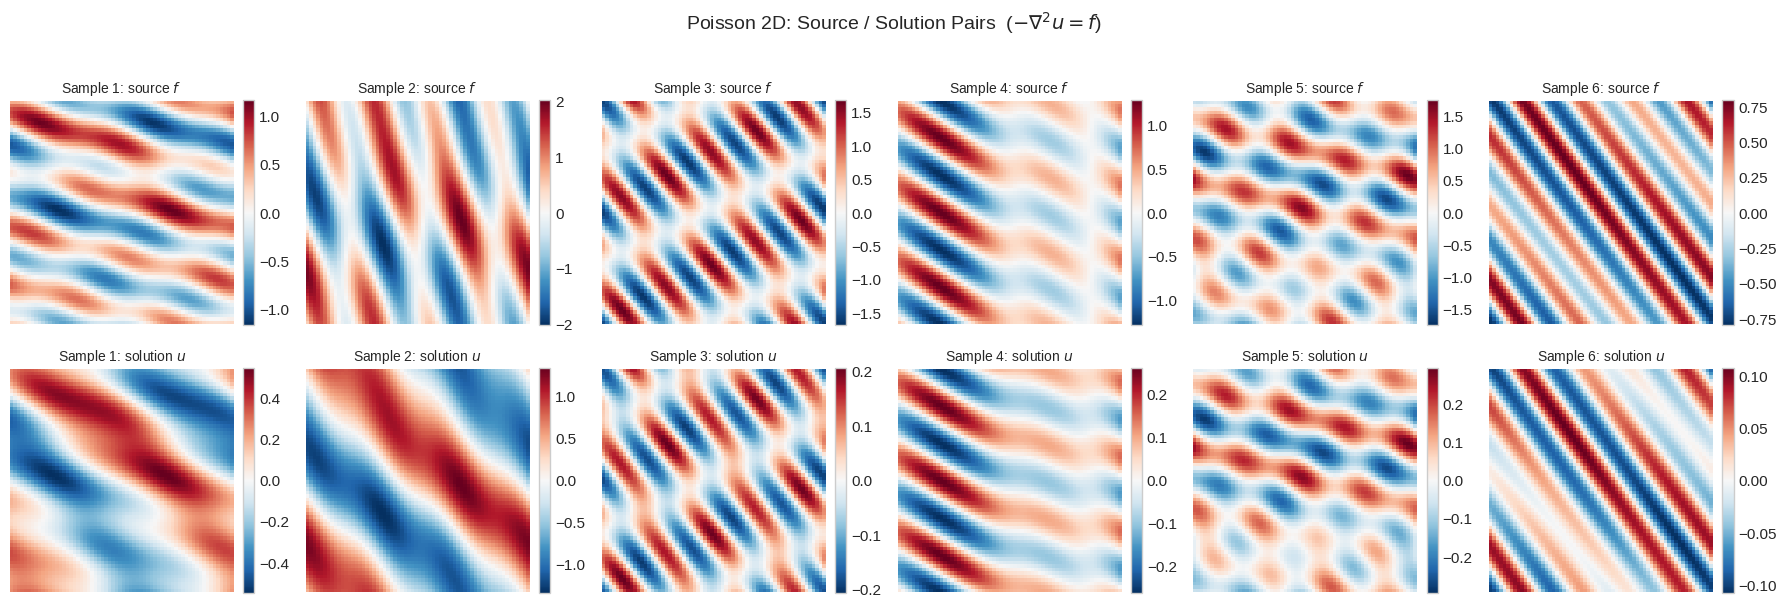

In [5]:
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))

for i in range(n_show):
    vmax_f = np.abs(source[i, 0]).max()
    im1 = axes[0, i].imshow(source[i, 0], cmap='RdBu_r', origin='lower',
                             norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_f, vmax=vmax_f))
    axes[0, i].set_title(f'Sample {i+1}: source $f$', fontsize=10)
    axes[0, i].axis('off')
    plt.colorbar(im1, ax=axes[0, i], fraction=0.046, pad=0.04)

    vmax_u = np.abs(solution[i, 0]).max()
    im2 = axes[1, i].imshow(solution[i, 0], cmap='RdBu_r', origin='lower',
                             norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_u, vmax=vmax_u))
    axes[1, i].set_title(f'Sample {i+1}: solution $u$', fontsize=10)
    axes[1, i].axis('off')
    plt.colorbar(im2, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.suptitle('Poisson 2D: Source / Solution Pairs  ($-\\nabla^2 u = f$)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Value & Norm Distributions

Pixel-value histograms and per-sample $L^2$-norm distributions for both fields.

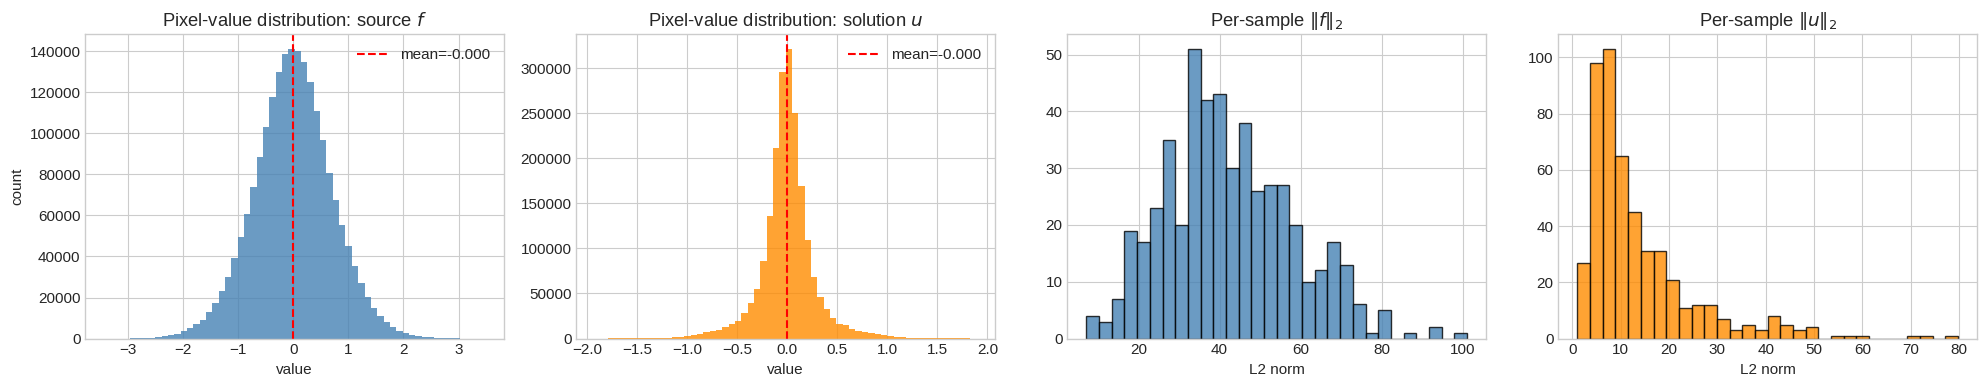

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(source.flatten(), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(source.mean(), color='red', linestyle='--', label=f'mean={source.mean():.3f}')
axes[0].set_title('Pixel-value distribution: source $f$')
axes[0].set_xlabel('value')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].hist(solution.flatten(), bins=60, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].axvline(solution.mean(), color='red', linestyle='--', label=f'mean={solution.mean():.3f}')
axes[1].set_title('Pixel-value distribution: solution $u$')
axes[1].set_xlabel('value')
axes[1].legend()

axes[2].hist(source_norms, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[2].set_title('Per-sample $\\|f\\|_2$')
axes[2].set_xlabel('L2 norm')

axes[3].hist(solution_norms, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
axes[3].set_title('Per-sample $\\|u\\|_2$')
axes[3].set_xlabel('L2 norm')

plt.tight_layout()
plt.show()

## 5. Spatial Statistics — Pixel-wise Mean & Std Maps

Since sources are random phase-shifted sine mixtures, we expect the dataset to be **spatially homogeneous**: no grid location should be systematically different from any other once averaged over enough samples.

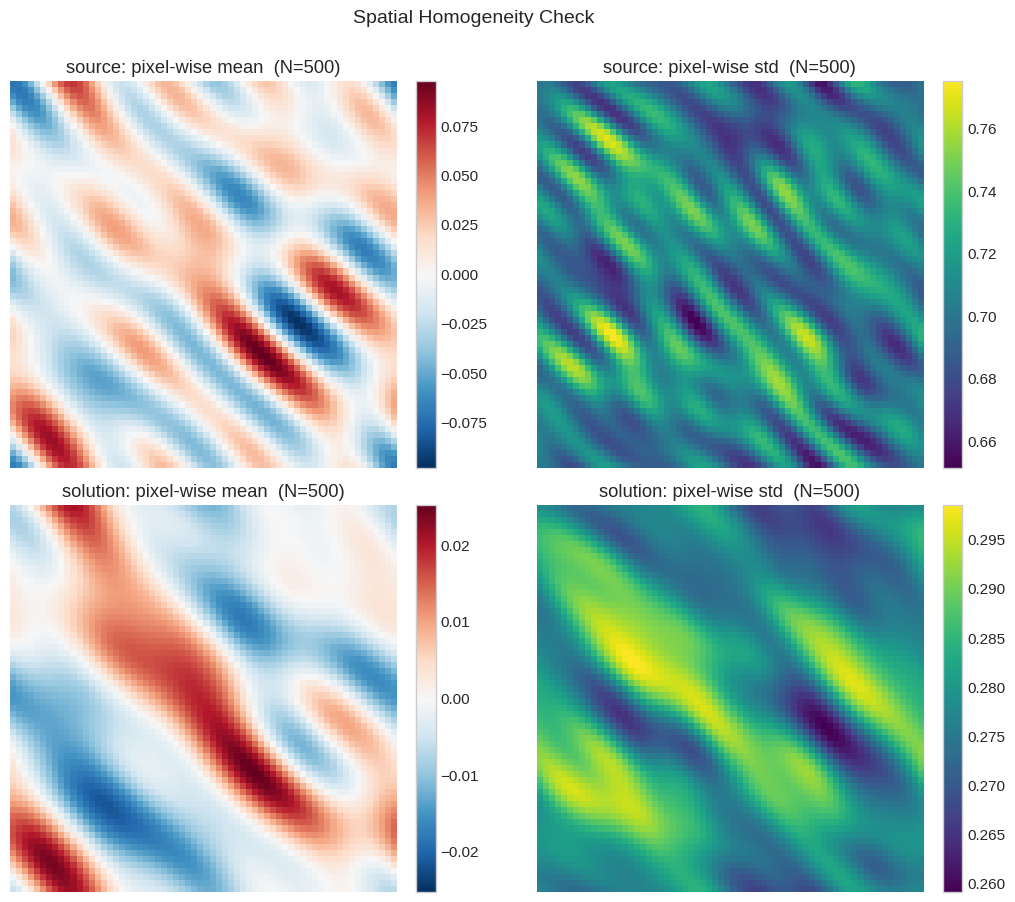

Std of the mean map (should be small vs. field std) — source: 0.0316, solution: 0.0098


In [7]:
source_mean_map = source[:, 0].mean(axis=0)
source_std_map = source[:, 0].std(axis=0)
solution_mean_map = solution[:, 0].mean(axis=0)
solution_std_map = solution[:, 0].std(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
maps = [
    (source_mean_map, 'source: pixel-wise mean', 'RdBu_r', True),
    (source_std_map, 'source: pixel-wise std', 'viridis', False),
    (solution_mean_map, 'solution: pixel-wise mean', 'RdBu_r', True),
    (solution_std_map, 'solution: pixel-wise std', 'viridis', False),
]
for ax, (field_map, title, cmap, diverging) in zip(axes.flat, maps):
    if diverging:
        vmax = np.abs(field_map).max()
        im = ax.imshow(field_map, cmap=cmap, origin='lower',
                        norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=max(vmax, 1e-8)))
    else:
        im = ax.imshow(field_map, cmap=cmap, origin='lower')
    ax.set_title(f'{title}  (N={n_samples})')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Spatial Homogeneity Check', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

print(f"Std of the mean map (should be small vs. field std) — "
      f"source: {source_mean_map.std():.4f}, solution: {solution_mean_map.std():.4f}")

## 6. Spectral Analysis

The Poisson solve is a division by $|k|^2$ in Fourier space, so the solution's radially-averaged power spectrum should sit roughly $|k|^4$ **below** the source's (power ∝ amplitude², and amplitude is damped by $|k|^2$).

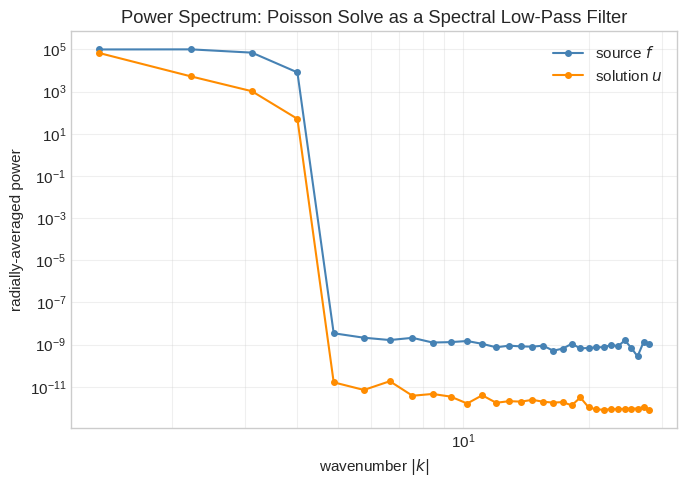

In [8]:
def radial_power_spectrum(fields, domain_extent):
    """Radially-averaged power spectrum, averaged over the sample (batch) axis.

    fields: (N, H, W) real array.
    Returns (k_bins, power) with k_bins the angular wavenumber |k|.
    """
    N = fields.shape[0]
    H, W = fields.shape[-2:]
    fft = np.fft.fft2(fields, axes=(-2, -1))
    power = (np.abs(fft) ** 2).mean(axis=0)  # (H, W), averaged over samples

    freqs = 2 * np.pi * np.fft.fftfreq(H, d=domain_extent / H)
    kx, ky = np.meshgrid(freqs, freqs, indexing='ij')
    kmag = np.sqrt(kx ** 2 + ky ** 2).flatten()
    power_flat = power.flatten()

    n_bins = H // 2
    bin_edges = np.linspace(0, kmag.max(), n_bins + 1)
    bin_idx = np.digitize(kmag, bin_edges)
    radial = np.array([
        power_flat[bin_idx == i].mean() if np.any(bin_idx == i) else np.nan
        for i in range(1, n_bins + 1)
    ])
    k_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return k_centers, radial


k_src, p_src = radial_power_spectrum(source[:, 0], poisson_cfg.domain_extent)
k_sol, p_sol = radial_power_spectrum(solution[:, 0], poisson_cfg.domain_extent)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(k_src[1:], p_src[1:], 'o-', color='steelblue', label='source $f$', markersize=4)
ax.loglog(k_sol[1:], p_sol[1:], 'o-', color='darkorange', label='solution $u$', markersize=4)
ax.set_xlabel('wavenumber $|k|$')
ax.set_ylabel('radially-averaged power')
ax.set_title('Power Spectrum: Poisson Solve as a Spectral Low-Pass Filter')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sanity Check — Do the Pairs Actually Satisfy $-\nabla^2 u = f$?

We independently recompute $-\nabla^2 u$ via an FFT-based spectral Laplacian and compare it to $f$ (mean-removed, since the equation only determines $u$ up to the source's zero mode). This validates the dataset end-to-end rather than trusting the solver as a black box.

max |source|:        3.4805
max |residual|:      1.03e-04   (spectral round-off, not a modeling error)
relative L2 error:   8.26e-06


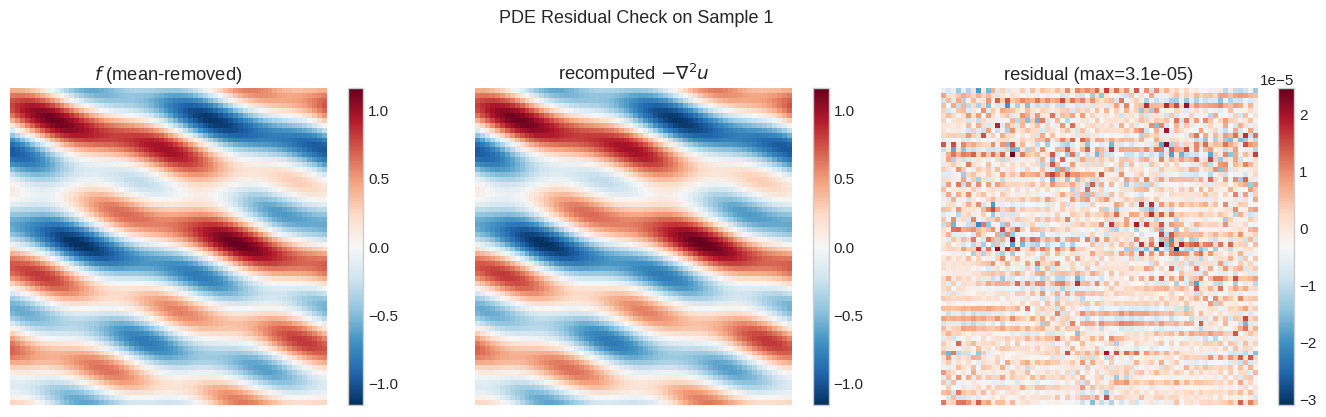

In [9]:
def spectral_negative_laplacian(u, domain_extent):
    """Compute -laplacian(u) via FFT, independent of the solver's own machinery."""
    N = u.shape[-1]
    k = 2 * np.pi * np.fft.fftfreq(N, d=domain_extent / N)
    kx, ky = np.meshgrid(k, k, indexing='ij')
    neg_lap_hat = (kx ** 2 + ky ** 2)  # symbol of -laplacian
    u_hat = np.fft.fft2(u, axes=(-2, -1))
    return np.fft.ifft2(neg_lap_hat[None] * u_hat, axes=(-2, -1)).real


recomputed_f = spectral_negative_laplacian(solution[:, 0], poisson_cfg.domain_extent)
source_zero_mean = source[:, 0] - source[:, 0].mean(axis=(-2, -1), keepdims=True)
residual = recomputed_f - source_zero_mean

print(f"max |source|:        {np.abs(source_zero_mean).max():.4f}")
print(f"max |residual|:      {np.abs(residual).max():.2e}   (spectral round-off, not a modeling error)")
print(f"relative L2 error:   {np.linalg.norm(residual) / np.linalg.norm(source_zero_mean):.2e}")

# Visual check on one sample
i = 0
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmax = np.abs(source_zero_mean[i]).max()
im0 = axes[0].imshow(source_zero_mean[i], cmap='RdBu_r', origin='lower',
                      norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax))
axes[0].set_title('$f$ (mean-removed)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(recomputed_f[i], cmap='RdBu_r', origin='lower',
                      norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax))
axes[1].set_title('recomputed $-\\nabla^2 u$')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(residual[i], cmap='RdBu_r', origin='lower')
axes[2].set_title(f'residual (max={np.abs(residual[i]).max():.1e})')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis('off')
plt.suptitle('PDE Residual Check on Sample 1', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 8. Effect of `source_max_mode` / `source_num_terms`

`source_max_mode` caps the highest wavenumber a sine term can use, and `source_num_terms` sets how many sine terms are summed. Higher values → more complex, higher-frequency sources (and, since the operator low-passes, proportionally *more* smoothing gets applied to reach the solution).

Generated Poisson 2D dataset: 4 samples, 64x64 grid


Generated Poisson 2D dataset: 4 samples, 64x64 grid


Generated Poisson 2D dataset: 4 samples, 64x64 grid


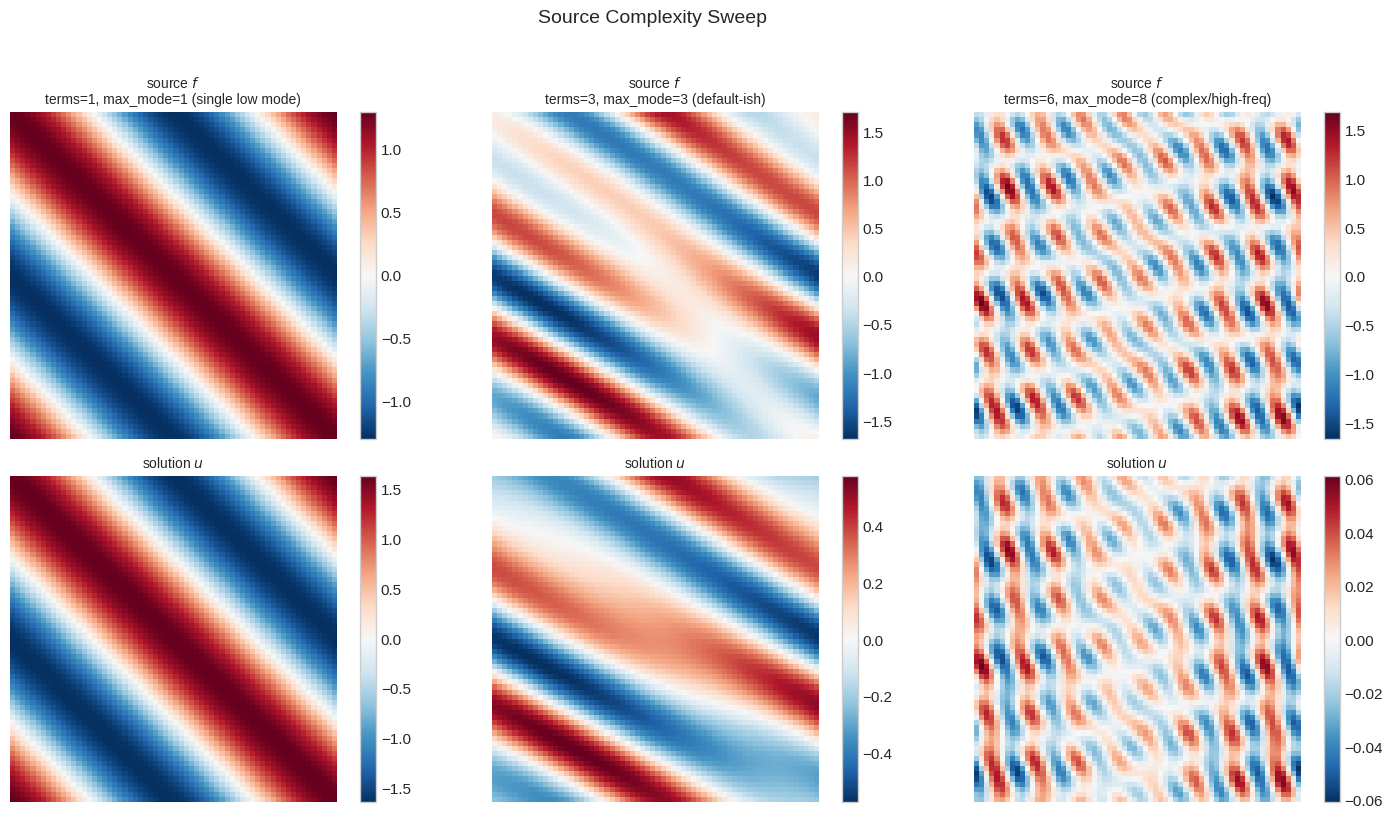

In [10]:
sweep_configs = [
    dict(source_num_terms=1, source_max_mode=1, label='terms=1, max_mode=1 (single low mode)'),
    dict(source_num_terms=3, source_max_mode=3, label='terms=3, max_mode=3 (default-ish)'),
    dict(source_num_terms=6, source_max_mode=8, label='terms=6, max_mode=8 (complex/high-freq)'),
]

fig, axes = plt.subplots(2, len(sweep_configs), figsize=(5 * len(sweep_configs), 8))

for j, sweep in enumerate(sweep_configs):
    cfg_j = PoissonConfig(
        num_spatial_dims=2, num_points=64, domain_extent=10.0,
        num_samples=4, seed=0,
        source_num_terms=sweep['source_num_terms'],
        source_max_mode=sweep['source_max_mode'],
    )
    ds_j = PoissonGenerator(config=cfg_j).generate()
    d_j = ds_j.get_raw_data()
    f_j = d_j['source'][0, 0].numpy()
    u_j = d_j['solution'][0, 0].numpy()

    im0 = axes[0, j].imshow(f_j, cmap='RdBu_r', origin='lower')
    axes[0, j].set_title(f"source $f$\n{sweep['label']}", fontsize=10)
    axes[0, j].axis('off')
    plt.colorbar(im0, ax=axes[0, j], fraction=0.046)

    im1 = axes[1, j].imshow(u_j, cmap='RdBu_r', origin='lower')
    axes[1, j].set_title('solution $u$', fontsize=10)
    axes[1, j].axis('off')
    plt.colorbar(im1, ax=axes[1, j], fraction=0.046)

plt.suptitle('Source Complexity Sweep', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Inverse Problem: Partial, Noisy Observations

For `problem='inverse'`, the roles flip: the model observes (a noisy, partially masked) **solution** $u$ and must recover the **source** $f$. `obs_noise_std` adds Gaussian measurement noise and `obs_mask_fraction` controls what fraction of grid points are visible; `__getitem__` concatenates the binary mask onto the input as an extra channel.

Generated Poisson 2D dataset: 8 samples, 64x64 grid
Data keys: ['source', 'solution', 'obs_mask']
input shape (obs + mask channels): torch.Size([2, 64, 64])
target shape (source):             torch.Size([1, 64, 64])


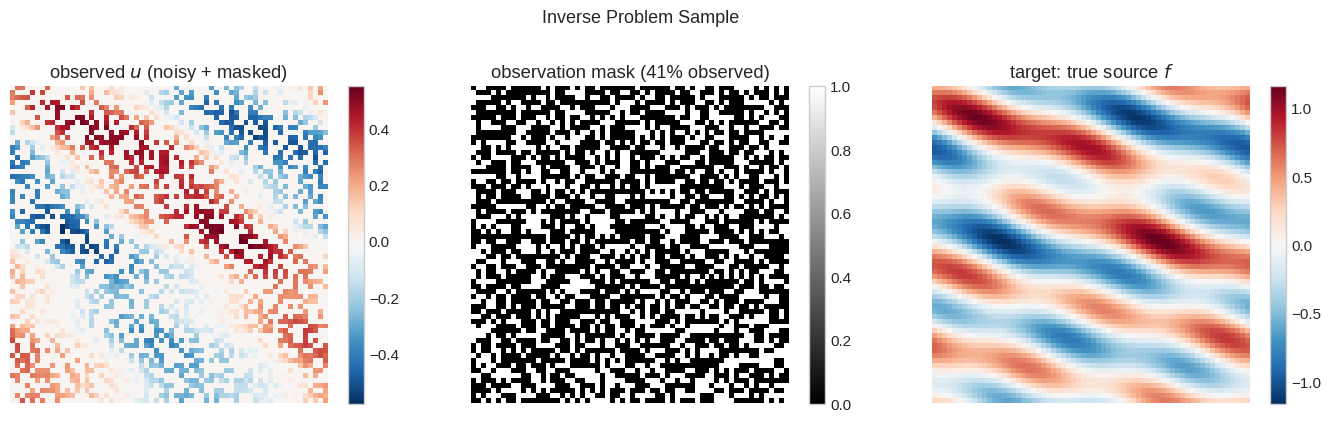

In [11]:
poisson_inv_cfg = PoissonConfig(
    num_spatial_dims=2, num_points=64, domain_extent=10.0,
    num_samples=8, seed=42,           # same seed -> same underlying (f, u) as the forward dataset
    source_num_terms=4, source_max_mode=4,
    obs_noise_std=0.02,                # measurement noise on u
    obs_mask_fraction=0.4,             # only 40% of grid points observed
)
poisson_inv_ds = PoissonGenerator(config=poisson_inv_cfg).generate(problem='inverse')
inv_sample = poisson_inv_ds[0]

print(f"Data keys: {list(poisson_inv_ds.get_raw_data().keys())}")
print(f"input shape (obs + mask channels): {inv_sample['input'].shape}")
print(f"target shape (source):             {inv_sample['target'].shape}")

obs_field = inv_sample['input'][0].numpy()   # noisy, masked solution
mask = inv_sample['obs_mask'][0].numpy()
target_source = inv_sample['target'][0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(obs_field, cmap='RdBu_r', origin='lower')
axes[0].set_title('observed $u$ (noisy + masked)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mask, cmap='gray', origin='lower', vmin=0, vmax=1)
axes[1].set_title(f'observation mask ({mask.mean() * 100:.0f}% observed)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(target_source, cmap='RdBu_r', origin='lower')
axes[2].set_title('target: true source $f$')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis('off')
plt.suptitle('Inverse Problem Sample', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 10. Field Normalization

`source` and `solution` live on very different scales (see §2: solution std is roughly half of source std, since the Poisson operator damps amplitude). `FieldNormalizer` standardizes each field independently to zero mean / unit variance — fit on a training split and reused verbatim on val/test.

In [12]:
normalizer = FieldNormalizer.from_dataset(poisson_dataset)
poisson_dataset.set_normalizer(normalizer)

sample = poisson_dataset[0]
print(f"Fitted fields: {normalizer.fields}")
print(f"Raw    input  mean/std: {source[0,0].mean():+.4f} / {source[0,0].std():.4f}")
print(f"Normed input  mean/std: {sample['input'].mean():+.4f} / {sample['input'].std():.4f}")
print(f"Raw    target mean/std: {solution[0,0].mean():+.4f} / {solution[0,0].std():.4f}")
print(f"Normed target mean/std: {sample['target'].mean():+.4f} / {sample['target'].std():.4f}")

# Detach the normalizer again so later cells keep working with raw-scale data
poisson_dataset.set_normalizer(None)

Fitted fields: ['solution', 'source']
Raw    input  mean/std: -0.0000 / 0.4969
Normed input  mean/std: -0.0000 / 0.7016
Raw    target mean/std: -0.0000 / 0.2818
Normed target mean/std: +0.0000 / 1.0032
